# Q6: Outlier Detection (Z-score and IQR) - BSDS500 Image Statistics

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE = "/home/claude/dataset"
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")
IMAGES_TRAIN = os.path.join(BASE, "images", "train")

### Compute one summary-statistics row per image

In [2]:
def image_summary_features(images_dir):
    filenames = sorted(f for f in os.listdir(images_dir) if f.lower().endswith(IMAGE_EXTENSIONS))
    rows = []
    for fname in filenames:
        img = np.array(Image.open(os.path.join(images_dir, fname)).convert("RGB"), dtype=float) / 255.0
        gray = img.mean(axis=2)
        grad_y = np.abs(np.diff(gray, axis=0, prepend=gray[:1, :]))
        grad_x = np.abs(np.diff(gray, axis=1, prepend=gray[:, :1]))
        grad_mag = np.sqrt(grad_x ** 2 + grad_y ** 2)
        rows.append({
            "filename": fname,
            "mean_R": img[:, :, 0].mean(), "mean_G": img[:, :, 1].mean(), "mean_B": img[:, :, 2].mean(),
            "mean_gray": gray.mean(), "std_gray": gray.std(),
            "mean_gradient": grad_mag.mean(),
        })
    return pd.DataFrame(rows)

df = image_summary_features(IMAGES_TRAIN)
print(df.head())
print("Shape:", df.shape)

     filename    mean_R    mean_G    mean_B  mean_gray  std_gray  \
0  100075.jpg  0.330823  0.398670  0.349791   0.359761  0.138263   
1  100080.jpg  0.375695  0.423569  0.343206   0.380823  0.118581   
2  100098.jpg  0.489597  0.530356  0.490327   0.503427  0.311213   
3  103041.jpg  0.348072  0.385852  0.381568   0.371831  0.150579   
4  104022.jpg  0.390536  0.405374  0.353638   0.383183  0.101143   

   mean_gradient  
0       0.049677  
1       0.019343  
2       0.101289  
3       0.034266  
4       0.045753  
Shape: (200, 7)


### Basic statistics

In [3]:
numeric_cols = ["mean_R", "mean_G", "mean_B", "mean_gray", "std_gray", "mean_gradient"]
print(df[numeric_cols].describe())

           mean_R      mean_G      mean_B   mean_gray    std_gray  \
count  200.000000  200.000000  200.000000  200.000000  200.000000   
mean     0.434245    0.443028    0.367067    0.414780    0.189535   
std      0.122469    0.113453    0.142839    0.111496    0.055428   
min      0.068810    0.139114    0.069144    0.122972    0.046043   
25%      0.351170    0.370335    0.264065    0.340214    0.152686   
50%      0.439559    0.444559    0.368451    0.425560    0.186265   
75%      0.520214    0.516472    0.454699    0.494614    0.227032   
max      0.769517    0.748626    0.782652    0.731274    0.326676   

       mean_gradient  
count     200.000000  
mean        0.057093  
std         0.026873  
min         0.007173  
25%         0.038388  
50%         0.054939  
75%         0.072230  
max         0.150146  


### Z-score method on mean_gray

In [4]:
col = df["mean_gray"]
col_mean, col_std = col.mean(), col.std()
z_scores = (col - col_mean) / col_std
z_outliers = df[np.abs(z_scores) > 3]
print("Z-score outliers in mean_gray:", len(z_outliers))
print(z_outliers[["filename", "mean_gray"]])

Z-score outliers in mean_gray: 0
Empty DataFrame
Columns: [filename, mean_gray]
Index: []


### IQR method on mean_gray

In [5]:
q1 = col.quantile(0.25)
q3 = col.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
iqr_outliers = df[(col < lower_fence) | (col > upper_fence)]
print("Q1:", round(q1, 4), " Q3:", round(q3, 4), " IQR:", round(iqr, 4))
print("Lower fence:", round(lower_fence, 4), " Upper fence:", round(upper_fence, 4))
print("IQR outliers in mean_gray:", len(iqr_outliers))
print(iqr_outliers[["filename", "mean_gray"]])

Q1: 0.3402  Q3: 0.4946  IQR: 0.1544
Lower fence: 0.1086  Upper fence: 0.7262
IQR outliers in mean_gray: 1
       filename  mean_gray
108  245051.jpg   0.731274


### Repeat both methods on mean_gradient (texture/edge density)

In [6]:
grad_col = df["mean_gradient"]
grad_mean, grad_std = grad_col.mean(), grad_col.std()
grad_z = (grad_col - grad_mean) / grad_std
z_outliers_grad = df[np.abs(grad_z) > 3]

q1_g, q3_g = grad_col.quantile(0.25), grad_col.quantile(0.75)
iqr_g = q3_g - q1_g
lower_g = q1_g - 1.5 * iqr_g
upper_g = q3_g + 1.5 * iqr_g
iqr_outliers_grad = df[(grad_col < lower_g) | (grad_col > upper_g)]

print("Z-score outliers in mean_gradient:", len(z_outliers_grad))
print("IQR outliers in mean_gradient:", len(iqr_outliers_grad))

Z-score outliers in mean_gradient: 3
IQR outliers in mean_gradient: 5


### Treat outliers by capping (winsorizing)

In [7]:
mean_gray_capped = col.clip(lower=lower_fence, upper=upper_fence)
mean_gradient_capped = grad_col.clip(lower=lower_g, upper=upper_g)
print("mean_gray std before capping:", round(col.std(), 4), " after:", round(mean_gray_capped.std(), 4))
print("mean_gradient std before capping:", round(grad_col.std(), 4), " after:", round(mean_gradient_capped.std(), 4))

mean_gray std before capping: 0.1115  after: 0.1114
mean_gradient std before capping: 0.0269  after: 0.0256


### Visualize before/after with boxplots

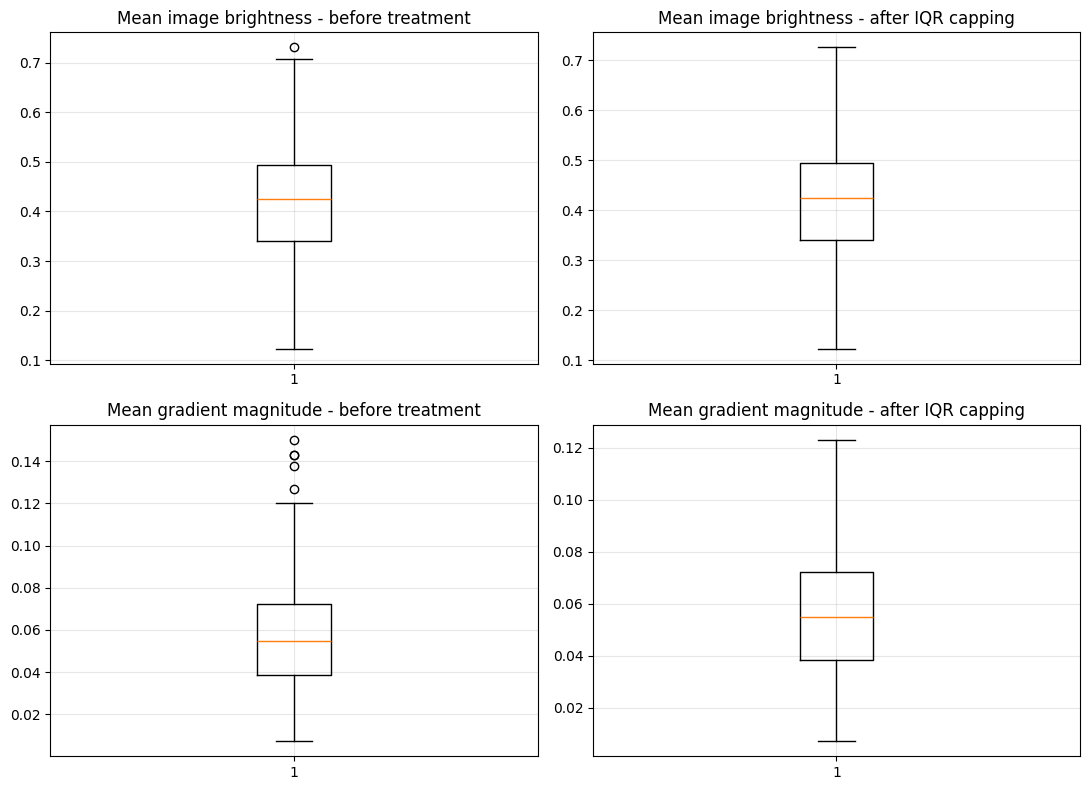

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].boxplot(col)
axes[0, 0].set_title("Mean image brightness - before treatment")
axes[0, 1].boxplot(mean_gray_capped)
axes[0, 1].set_title("Mean image brightness - after IQR capping")

axes[1, 0].boxplot(grad_col)
axes[1, 0].set_title("Mean gradient magnitude - before treatment")
axes[1, 1].boxplot(mean_gradient_capped)
axes[1, 1].set_title("Mean gradient magnitude - after IQR capping")

for ax in axes.ravel():
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()